# GNN — 2 Lepton 2 Taus (Run 2 + Run 3 + Combined)

Graph-neural-network counterpart to `DNN_2l2tau.ipynb`'s flat-feature MLP,
on the same 2l2tau data (`Evie/PPSSP_2026/2l2tau/run2` and `.../run3`), same
preselection, same leakage-free feature policy, and the same deterministic
80/10/10 train/val/test split - so results are directly comparable.

**Representation change.** The MLP concatenates every event into one flat
feature vector (kinematics + hand-engineered pairwise variables like `dR_*`,
`m_*`, `HT_*`). This notebook instead represents each event as a small graph:
one node per reconstructed physics object (lepton1, lepton2, tau1, tau2,
jet1, jet2, MET), each carrying only its own kinematics, with a
fully-connected edge set within the event. The hand-engineered
pairwise/aggregate variables are deliberately **not** given to the model -
the point of the GNN is to see how much of that relational information
(angular separations, invariant masses, combined momenta) message passing
can recover on its own from raw 4-vectors.

**Node count vs 1l2tau.** This channel has one extra node (lepton2) instead
of a single lepton - 7 nodes/event instead of 6.

**Jets aren't guaranteed here.** Unlike 1l2tau (`n_jet >= 2` in the
preselection), 2l2tau's preselection does not require any jets - `j1_*`/
`j2_*` are frequently missing (sentinel-masked to NaN by `clean_data`, then
median-imputed same as any other missing value). An imputed "typical jet"
for an event with no real jet is a modelling compromise worth flagging in
your write-up, not a bug - a `has_jet1`/`has_jet2` indicator feature would
be a reasonable follow-up if you want the model to distinguish real vs
imputed jets explicitly.

**A caveat on the node schema below.** `DNN_2l2tau.ipynb` builds its
feature list dynamically (`discover_common_features`), so I could only
confirm a subset of raw per-object branch names from what its feature-
importance/correlation cells happened to print (`l1_e`, `l1_charge`,
`l2_e`, `l2_charge`, `j1_pt`, `j2_pt`, `j2_eta`, `tau1_pt`, `tau2_pt`,
`met_met`, `met_sumet`). Columns like `l1_eta`/`l1_phi`/`l2_eta`/`l2_phi`/
`l1_pdg`/`l2_pdg`/`j1_eta`/`j1_phi`/`j2_phi`/`met_phi`/`tau1_eta`/
`tau1_phi`/`tau2_eta`/`tau2_phi` are assumed present by analogy with the
1l2tau ntuples (same production, same tree), but **not individually
verified** - the schema cell below has a runtime `assert` that will name
the exact missing column if any of these guesses are wrong, so a failure
there is expected to be a quick one-line fix, not a sign anything else is
broken.

**Scope.** Mirrors the 1l2tau GNN notebook's structure exactly: data
loading, graph construction, model, training with early stopping, ROC/AUC
evaluation, a held-out test evaluation, and permutation importance (on the
raw per-object columns, not the ~80 flat MLP features) - for Run 2, then
Run 3, then Combined Run2+Run3, each reusing the Run 2 section's
functions/classes/schema unchanged with `_run3`/`_comb`-suffixed variables.

## Libraries

In [ ]:
import os

os.environ["PYTHONHASHSEED"] = "42"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import random
from pathlib import Path

import numpy as np
import pandas as pd
import uproot
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

from torch_geometric.nn import GATv2Conv, global_mean_pool, global_max_pool

RANDOM_STATE = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(seed: int = RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)


set_seed(RANDOM_STATE)
print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:
# ---------------------------------------------------------------------------
# Paths - 2 leptons + 2 taus, Run 2 and Run 3 (same source files as
# DNN_2l2tau.ipynb / Final_Notebooks/2L2Tau_Master_Pipeline.ipynb).
# ---------------------------------------------------------------------------

BASE_DIR_RUN2 = Path("PPSSP_2026/2l2tau/run2")
BASE_DIR_RUN3 = Path("PPSSP_2026/2l2tau/run3")

BASE_DIR = BASE_DIR_RUN2
ACTIVE_RUN = "Run 2"
TREE_NAME = "AnalysisMiniTree"

# ---------------------------------------------------------------------------
# Preselection (see repo README.md, "2 Lepton 2 Taus")
# ---------------------------------------------------------------------------

PRESELECTION = "(n_b_jet == 0) & (l1_charge * l2_charge < 0) & (mZ_cut > 0)"

# ---------------------------------------------------------------------------
# Processes: filename + label (1 = signal, 0 = background)
# ---------------------------------------------------------------------------

FILES = {
    "signal_ggF": ("signal_ggF.root", 1),
    "signal_VBF": ("signal_VBF.root", 1),
    "Diboson":    ("diboson.root",    0),
    "Zjets":      ("Zjets.root",      0),
    "Wjets":      ("Wjets.root",      0),
    "ttbar":      ("ttbar.root",      0),
    "tops":       ("tops.root",       0),
    "SingleH":    ("singleH.root",    0),
    "Vgamma":     ("Vgamma.root",     0),
    "VVV":        ("VVV.root",        0),
}

WEIGHT_PARTS = ["weight", "weights"]  # raw branches; w_phys = their product

# ---------------------------------------------------------------------------
# Leakage-free feature-selection policy - IDENTICAL to DNN_2l2tau.ipynb, so
# this notebook builds graph nodes only out of branches the MLP was also
# allowed to see.
# ---------------------------------------------------------------------------

BLOCK_SUBSTR = ["weight", "effsf", "_ff", "truth", "istrue", "fake", "anti",
                "dsid", "eventnumber", "_RNNTight", "_isOS", "_d0sig"]
BLOCK_EXACT = {
    "n_b_jet", "pass2l2tau", "tau1_RNNJetScoreSigTrans", "tau2_RNNJetScoreSigTrans",
    "pair_isOStaus", "pair_isOSlep1lep2", "tau2_baseline_RNNTight", "l1_d0sig",
    "tau1_charge", "tau2_charge", "mZ_veto", "tau1_decayMode", "tau2_decayMode",
    "tau1_nprong", "tau2_nprong", "mZ_cut", "mZreq",
}

BLOCK_EXACT_LOWER = {b.lower() for b in BLOCK_EXACT}


def is_feature(branch: str) -> bool:
    lb = branch.lower()
    return lb not in BLOCK_EXACT_LOWER and not any(s.lower() in lb for s in BLOCK_SUBSTR)

## Data Loading Helpers

Identical to `DNN_2l2tau.ipynb`'s loaders - same discovery, same
preselection, same sentinel-to-NaN cleaning.

In [ ]:
def discover_common_features(base_dir, files=FILES, tree_name=TREE_NAME):
    common = None
    for fname, _ in files.values():
        keys = set(uproot.open({str(Path(base_dir) / fname): tree_name}).keys())
        common = keys if common is None else common & keys
    features = sorted(b for b in common if is_feature(b))
    print(f"{len(features)} candidate features (common to all {len(files)} processes, leakage-free)")
    return features


def load_run_data(base_dir, features, files=FILES, weight_parts=WEIGHT_PARTS,
                   preselection=PRESELECTION, tree_name=TREE_NAME, verbose=True):
    base_dir = Path(base_dir)
    dfs = []
    for proc, (fname, label) in files.items():
        tree = uproot.open({str(base_dir / fname): tree_name})
        df = tree.arrays(features + weight_parts, cut=preselection, library="pd")
        df["w_phys"] = df["weights"] * df["weight"]
        df["label"] = label
        df["process"] = proc
        dfs.append(df)
        if verbose:
            print(f"{proc:12s}: {len(df):>8d} events after preselection")
    return pd.concat(dfs, ignore_index=True)


def clean_data(data, features, verbose=True):
    data = data.copy()
    nun = data[features].nunique()
    const = nun[nun <= 1].index.tolist()
    features = [f for f in features if f not in const]
    data = data.drop(columns=const)
    if verbose:
        print(f"Dropped {len(const)} constant/empty features:\n  {sorted(const)}")
    for f in features:
        m = data[f] < -100
        if m.any():
            if verbose:
                print(f"  sentinel -> NaN: {f} ({m.mean():.1%})")
            data[f] = data[f].mask(m)
    if verbose:
        print(f"\n{len(features)} final features")
        print(f"Total: {len(data)} events | signal = {(data.label==1).sum()} | "
              f"background = {(data.label==0).sum()}")
        print(f"Yield (w_phys): signal = {data.loc[data.label==1,'w_phys'].sum():.2f} | "
              f"background = {data.loc[data.label==0,'w_phys'].sum():.2f}")
    return data, features

## Load Run 2 Data

In [ ]:
candidate_features = discover_common_features(BASE_DIR_RUN2)
data = load_run_data(BASE_DIR_RUN2, candidate_features)
data, features = clean_data(data, candidate_features)

print(f"\nLoaded {len(data)} events | {len(features)} leakage-free features available")

88 candidate features (common to all 10 processes, leakage-free)


signal_ggF  :    31959 events after preselection
signal_VBF  :     5598 events after preselection
Diboson     :    36877 events after preselection
Zjets       :     7746 events after preselection
Wjets       :       67 events after preselection
ttbar       :      331 events after preselection
tops        :     3832 events after preselection
SingleH     :     2946 events after preselection
Vgamma      :     2019 events after preselection
VVV         :     3593 events after preselection
Dropped 7 constant/empty features:
  ['dR_j1j2_l1', 'dR_j1j2_t1', 'dR_j1j2_t2', 'n_lep', 'tau1_base_id', 'tau2_base_id', 'xgb_score']

81 final features
Total: 94968 events | signal = 37557 | background = 57411
Yield (w_phys): signal = 0.42 | background = 1034.16

Loaded 94968 events | 81 leakage-free features available


## Sentinel Audit (-1)

Same diagnostic as `DNN_2l2tau.ipynb`: `clean_data` only masks `< -100`
sentinels to NaN; some branches instead default to exactly `-1`. Inspect
`neg1_df` below before deciding whether any belong in
`NEG1_SENTINEL_FEATURES` (kept empty here to match the MLP notebook's own
audited conclusion for `l1_charge`/`l2_charge`, which are legitimately
`-1`-valued, not undefined).

In [ ]:
NEG1_SENTINEL_FEATURES = set()

neg1_rows = []
for f in features:
    vals = data[f]
    frac_neg1 = (vals == -1).mean()
    if frac_neg1 == 0:
        continue
    above = vals[vals > -1]
    gap = (above.min() - (-1)) if len(above) else np.nan
    neg1_rows.append({"feature": f, "frac_exactly_-1": frac_neg1, "gap_to_next_value_above": gap})

neg1_df = pd.DataFrame(neg1_rows).sort_values("frac_exactly_-1", ascending=False)
print(f"{len(neg1_df)} / {len(features)} features have at least one row exactly equal to -1:")
print(neg1_df.to_string(index=False))

for f in NEG1_SENTINEL_FEATURES:
    data[f] = data[f].mask(data[f] == -1)

if NEG1_SENTINEL_FEATURES:
    print(f"\nMasked -1 -> NaN for: {sorted(NEG1_SENTINEL_FEATURES)}")
else:
    print("\nNEG1_SENTINEL_FEATURES is empty - no -1 values masked.")

2 / 81 features have at least one row exactly equal to -1:
  feature  frac_exactly_-1  gap_to_next_value_above
l1_charge         0.504833                      2.0
l2_charge         0.495167                      2.0

NEG1_SENTINEL_FEATURES is empty - no -1 values masked.


## Train/Validation/Test Split

Same deterministic two-stage stratified 80/10/10 split as `DNN_2l2tau.ipynb`,
cross-checked against its persisted TEST partition so both notebooks are
evaluated on the same held-out events.

In [ ]:
def make_fit_weights(labels, abs_weights):
    labels = np.asarray(labels)
    fit_weights = np.asarray(abs_weights, dtype=float).copy()
    sum_signal = fit_weights[labels == 1].sum()
    sum_background = fit_weights[labels == 0].sum()
    fit_weights[labels == 1] *= sum_background / sum_signal
    fit_weights *= len(fit_weights) / fit_weights.sum()
    return fit_weights


def make_3way_split(data, test_size=0.10, val_size=0.10, seed=RANDOM_STATE, extra_stratify_col=None):
    def _strata(df):
        if extra_stratify_col is not None:
            return df["label"].astype(str) + "_" + df[extra_stratify_col].astype(str)
        return df["label"]

    trainval_df, test_df = train_test_split(data, test_size=test_size, random_state=seed, stratify=_strata(data))
    val_frac_of_remaining = val_size / (1 - test_size)
    train_df, val_df = train_test_split(
        trainval_df, test_size=val_frac_of_remaining, random_state=seed, stratify=_strata(trainval_df)
    )

    for name, df in (("Train", train_df), ("Val", val_df), ("Test", test_df)):
        sig_n, bkg_n = int((df.label == 1).sum()), int((df.label == 0).sum())
        sig_y = df.loc[df.label == 1, "w_phys"].sum()
        bkg_y = df.loc[df.label == 0, "w_phys"].sum()
        print(f"{name:5s}: {len(df):>8d} events | signal = {sig_n:>7d} (yield={sig_y:>10.2f}) | "
              f"background = {bkg_n:>7d} (yield={bkg_y:>10.2f}) | "
              f"signal weight scale factor = {bkg_y / sig_y:.1f}")

    return train_df, val_df, test_df


def assert_same_test_partition(test_df, path):
    path = Path(path)
    if not path.exists():
        print(f"  (no prior test partition at {path} yet - nothing to cross-check)")
        return
    prior_df = uproot.open({str(path): "tree"}).arrays(library="pd")
    cols = sorted((set(test_df.columns) & set(prior_df.columns)) - {"run"})
    a = test_df[cols].sort_values(cols).reset_index(drop=True)
    b = prior_df[cols].sort_values(cols).reset_index(drop=True)
    pd.testing.assert_frame_equal(a, b, check_exact=False, rtol=1e-5, atol=1e-8, check_dtype=False)
    print(f"  cross-check OK: {path} test partition matches on {len(cols)} shared columns ({len(test_df)} rows)")


train_df, val_df, test_df = make_3way_split(data)

SPLIT_DIR_RUN2 = BASE_DIR_RUN2 / "splits"
assert_same_test_partition(test_df, SPLIT_DIR_RUN2 / "test.root")

Train:    75974 events | signal =   30045 (yield=      0.33) | background =   45929 (yield=    796.57) | signal weight scale factor = 2391.6
Val  :     9497 events | signal =    3756 (yield=      0.04) | background =    5741 (yield=    139.99) | signal weight scale factor = 3326.1
Test :     9497 events | signal =    3756 (yield=      0.04) | background =    5741 (yield=     97.60) | signal weight scale factor = 2352.7
  cross-check OK: PPSSP_2026/2l2tau/run2/splits/test.root test partition matches on 86 shared columns (9497 rows)


## Object / Node Schema

Seven nodes per event, one per reconstructed object - one more than
1l2tau's six, since this channel has two leptons instead of one.

| node    | source prefix | fields                          |
|---------|---------------|----------------------------------|
| lepton1 | `l1_`         | pt, eta, phi, e, charge, pdg (-> is_electron) |
| lepton2 | `l2_`         | pt, eta, phi, e, charge, pdg (-> is_electron) |
| tau1    | `tau1_`       | pt, eta, phi                     |
| tau2    | `tau2_`       | pt, eta, phi                     |
| jet1    | `j1_`         | pt, eta, phi, e                  |
| jet2    | `j2_`         | pt, eta, phi, e                  |
| MET     | `met_`        | met (-> pt slot), phi, sumet (-> e slot) |

Each node's feature vector is `[pt, eta, sin(phi), cos(phi), e, charge,
is_electron, is_lepton, is_tau, is_jet, is_met]` (11 dims, same as 1l2tau -
lepton1/lepton2 share the same `is_lepton` type slot). Fields that don't
apply to an object are zero-filled. `phi` is encoded as `(sin, cos)` rather
than a raw scaled scalar so its circular topology isn't broken by standard
scaling.

**Unlike 1l2tau, jets aren't guaranteed** (no `n_jet >= 2` in this
preselection) - `j1_*`/`j2_*` will be missing for a meaningful fraction of
events, median-imputed same as any other missing value (see intro caveat
above).

In [ ]:
OBJECT_COLUMNS = {
    "lepton1": {"pt": "l1_pt", "eta": "l1_eta", "phi": "l1_phi", "e": "l1_e", "charge": "l1_charge", "pdg": "l1_pdg"},
    "lepton2": {"pt": "l2_pt", "eta": "l2_eta", "phi": "l2_phi", "e": "l2_e", "charge": "l2_charge", "pdg": "l2_pdg"},
    "tau1":    {"pt": "tau1_pt", "eta": "tau1_eta", "phi": "tau1_phi"},
    "tau2":    {"pt": "tau2_pt", "eta": "tau2_eta", "phi": "tau2_phi"},
    "jet1":    {"pt": "j1_pt",   "eta": "j1_eta",   "phi": "j1_phi",   "e": "j1_e"},
    "jet2":    {"pt": "j2_pt",   "eta": "j2_eta",   "phi": "j2_phi",   "e": "j2_e"},
    "met":     {"pt": "met_met", "phi": "met_phi",  "e": "met_sumet"},
}
NODE_ORDER = ["lepton1", "lepton2", "tau1", "tau2", "jet1", "jet2", "met"]
NODE_TYPE = {"lepton1": "lepton", "lepton2": "lepton", "tau1": "tau", "tau2": "tau",
             "jet1": "jet", "jet2": "jet", "met": "met"}
TYPE_LIST = ["lepton", "tau", "jet", "met"]
N_NODES = len(NODE_ORDER)
N_NODE_FEATURES = 7 + len(TYPE_LIST)  # pt, eta, sin(phi), cos(phi), e, charge, is_electron + type one-hot

REQUIRED_OBJECT_COLUMNS = sorted({c for cols in OBJECT_COLUMNS.values() for c in cols.values()})
missing = [c for c in REQUIRED_OBJECT_COLUMNS if c not in features]
assert not missing, f"Node schema references columns dropped by clean_data / the leakage policy: {missing}"

CONTINUOUS_NODE_COLS = sorted({
    c for cols in OBJECT_COLUMNS.values() for k, c in cols.items() if k in ("pt", "eta", "e")
})

print(f"{N_NODES} nodes/event x {N_NODE_FEATURES} features/node")
print(f"{len(CONTINUOUS_NODE_COLS)} continuous columns to impute + scale: {CONTINUOUS_NODE_COLS}")

EDGE_INDEX = torch.tensor(
    [[i, j] for i in range(N_NODES) for j in range(N_NODES) if i != j],
    dtype=torch.long,
).t().contiguous().to(DEVICE)

_edge_index_cache = {}
_batch_vector_cache = {}


def get_batched_edge_index(batch_size):
    if batch_size not in _edge_index_cache:
        offsets = torch.arange(batch_size, device=DEVICE).repeat_interleave(EDGE_INDEX.shape[1]) * N_NODES
        _edge_index_cache[batch_size] = EDGE_INDEX.repeat(1, batch_size) + offsets
    return _edge_index_cache[batch_size]


def get_batch_vector(batch_size):
    if batch_size not in _batch_vector_cache:
        _batch_vector_cache[batch_size] = torch.arange(batch_size, device=DEVICE).repeat_interleave(N_NODES)
    return _batch_vector_cache[batch_size]


train_medians = train_df[REQUIRED_OBJECT_COLUMNS].median()

train_imp = train_df[REQUIRED_OBJECT_COLUMNS].fillna(train_medians)
val_imp = val_df[REQUIRED_OBJECT_COLUMNS].fillna(train_medians)
test_imp = test_df[REQUIRED_OBJECT_COLUMNS].fillna(train_medians)

scaler = StandardScaler()
train_scaled = train_imp.copy()
val_scaled = val_imp.copy()
test_scaled = test_imp.copy()
train_scaled[CONTINUOUS_NODE_COLS] = scaler.fit_transform(train_imp[CONTINUOUS_NODE_COLS])
val_scaled[CONTINUOUS_NODE_COLS] = scaler.transform(val_imp[CONTINUOUS_NODE_COLS])
test_scaled[CONTINUOUS_NODE_COLS] = scaler.transform(test_imp[CONTINUOUS_NODE_COLS])

assert np.isfinite(train_scaled.to_numpy()).all(), "NaN/inf reached the model input (train)"
assert np.isfinite(val_scaled.to_numpy()).all(), "NaN/inf reached the model input (val)"
assert np.isfinite(test_scaled.to_numpy()).all(), "NaN/inf reached the model input (test)"

print("Imputation + scaling done (fit on train only).")

7 nodes/event x 11 features/node
18 continuous columns to impute + scale: ['j1_e', 'j1_eta', 'j1_pt', 'j2_e', 'j2_eta', 'j2_pt', 'l1_e', 'l1_eta', 'l1_pt', 'l2_e', 'l2_eta', 'l2_pt', 'met_met', 'met_sumet', 'tau1_eta', 'tau1_pt', 'tau2_eta', 'tau2_pt']
Imputation + scaling done (fit on train only).


## Graph Construction

Vectorized build of the `(n_events, N_NODES, N_NODE_FEATURES)` node-feature
tensor for each split - GPU-resident, no PyG `DataLoader`.

In [ ]:
def stack_node_features(df_scaled, df_imp):
    n = len(df_scaled)
    node_arrays = []

    for name in NODE_ORDER:
        cols = OBJECT_COLUMNS[name]

        pt = df_scaled[cols["pt"]].to_numpy(dtype=np.float32)
        eta = df_scaled[cols["eta"]].to_numpy(dtype=np.float32) if "eta" in cols else np.zeros(n, dtype=np.float32)
        phi = df_imp[cols["phi"]].to_numpy(dtype=np.float32)
        e = df_scaled[cols["e"]].to_numpy(dtype=np.float32) if "e" in cols else np.zeros(n, dtype=np.float32)
        charge = df_imp[cols["charge"]].to_numpy(dtype=np.float32) if "charge" in cols else np.zeros(n, dtype=np.float32)
        is_electron = (
            (np.abs(df_imp[cols["pdg"]].to_numpy()) == 11).astype(np.float32)
            if "pdg" in cols else np.zeros(n, dtype=np.float32)
        )
        type_onehot = np.tile(
            np.array([float(NODE_TYPE[name] == t) for t in TYPE_LIST], dtype=np.float32), (n, 1)
        )

        node_arrays.append(np.column_stack(
            [pt, eta, np.sin(phi), np.cos(phi), e, charge, is_electron, type_onehot]
        ))

    return np.stack(node_arrays, axis=1)  # (n, N_NODES, N_NODE_FEATURES)


def build_graph_tensors(df_scaled, df_imp, df_raw, fit_weights=None):
    x = torch.from_numpy(stack_node_features(df_scaled, df_imp)).to(DEVICE)
    y = torch.from_numpy(df_raw["label"].to_numpy(dtype=np.float32)).to(DEVICE)
    w_abs = torch.from_numpy(np.abs(df_raw["w_phys"].to_numpy(dtype=np.float32))).to(DEVICE)
    w_fit = torch.from_numpy(fit_weights.astype(np.float32)).to(DEVICE) if fit_weights is not None else None
    return x, y, w_fit, w_abs


w_train_fit = make_fit_weights(train_df["label"].to_numpy(), np.abs(train_df["w_phys"].to_numpy()))

X_train, y_train, w_train_fit_t, w_train_eval_t = build_graph_tensors(train_scaled, train_imp, train_df, fit_weights=w_train_fit)
X_val, y_val_labels, _, w_val_abs = build_graph_tensors(val_scaled, val_imp, val_df)
X_test, y_test_labels, _, w_test_abs_t = build_graph_tensors(test_scaled, test_imp, test_df)

print(f"Built {X_train.shape[0]} train / {X_val.shape[0]} val / {X_test.shape[0]} test graphs (GPU-resident tensors)")
print(f"Node tensor shape per split: (n_events, {N_NODES}, {N_NODE_FEATURES})")

Built 75974 train / 9497 val / 9497 test graphs (GPU-resident tensors)
Node tensor shape per split: (n_events, 7, 11)


## GNN Model

Two `GATv2Conv` message-passing layers, mean+max graph-level pooling, then
a small MLP head - identical architecture to the 1l2tau GNN (only
`in_channels` differs implicitly via `N_NODE_FEATURES`, which is the same
11 here since the extra node doesn't add feature dimensions).

In [ ]:
BATCH_SIZE = 8192
DEFAULT_HIDDEN_CHANNELS = 64
DEFAULT_DROPOUT = 0.3


class ObjectGNN(nn.Module):
    def __init__(self, in_channels, hidden_channels=DEFAULT_HIDDEN_CHANNELS, dropout=DEFAULT_DROPOUT):
        super().__init__()
        self.conv1 = GATv2Conv(in_channels, hidden_channels)
        self.conv2 = GATv2Conv(hidden_channels, hidden_channels)
        self.dropout = dropout
        self.head = nn.Sequential(
            nn.Linear(hidden_channels * 2, hidden_channels), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_channels, hidden_channels // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_channels // 2, 1),
        )

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = torch.cat([global_mean_pool(x, batch), global_max_pool(x, batch)], dim=1)
        return self.head(x).squeeze(-1)


def build_model(hidden_channels=DEFAULT_HIDDEN_CHANNELS, dropout=DEFAULT_DROPOUT, in_channels=None):
    if in_channels is None:
        in_channels = N_NODE_FEATURES
    return ObjectGNN(in_channels=in_channels, hidden_channels=hidden_channels, dropout=dropout).to(DEVICE)


model = build_model()
print(model)

ObjectGNN(
  (conv1): GATv2Conv(11, 64, heads=1)
  (conv2): GATv2Conv(64, 64, heads=1)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


## Training Loop

Weighted binary cross-entropy, Adam optimizer, early stopping on weighted
validation AUC - same convention as `DNN_2l2tau.ipynb`'s `train_model`.

In [ ]:
N_EPOCHS = 50
PATIENCE = 10
LEARNING_RATE = 1e-3


def run_epoch(model, X, y, w, criterion, optimizer, train, batch_size=BATCH_SIZE):
    model.train(train)
    n = X.shape[0]
    order = torch.randperm(n, device=DEVICE) if train else torch.arange(n, device=DEVICE)

    total_loss = torch.zeros((), device=DEVICE)
    total_weight = torch.zeros((), device=DEVICE)
    all_labels, all_probs, all_weights = [], [], []

    with torch.set_grad_enabled(train):
        for start in range(0, n, batch_size):
            idx = order[start:start + batch_size]
            b = idx.shape[0]

            bx = X[idx].reshape(b * N_NODES, N_NODE_FEATURES)
            by = y[idx]
            bw = w[idx]

            logits = model(bx, get_batched_edge_index(b), get_batch_vector(b))
            loss = (criterion(logits, by) * bw).sum() / bw.sum()

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            bw_sum = bw.sum().detach()
            total_loss += loss.detach() * bw_sum
            total_weight += bw_sum
            all_labels.append(by.detach())
            all_probs.append(torch.sigmoid(logits).detach())
            all_weights.append(bw.detach())

    labels = torch.cat(all_labels).cpu().numpy()
    probs = torch.cat(all_probs).cpu().numpy()
    weights = torch.cat(all_weights).cpu().numpy()
    auc = roc_auc_score(labels, probs, sample_weight=weights)

    return (total_loss / total_weight).item(), auc


def score_dataset(model, X, batch_size=BATCH_SIZE):
    model.eval()
    all_p = []
    with torch.no_grad():
        for start in range(0, X.shape[0], batch_size):
            bx = X[start:start + batch_size]
            b = bx.shape[0]
            logits = model(bx.reshape(b * N_NODES, N_NODE_FEATURES), get_batched_edge_index(b), get_batch_vector(b))
            all_p.append(torch.sigmoid(logits))
    return torch.cat(all_p)


def train_model(hidden_channels=DEFAULT_HIDDEN_CHANNELS, dropout=DEFAULT_DROPOUT, lr=LEARNING_RATE,
                 n_epochs=N_EPOCHS, patience=PATIENCE, verbose=True,
                 X_train_data=None, y_train_data=None, w_train_fit_data=None, w_train_eval_data=None,
                 X_val_data=None, y_val_data=None, w_val_data=None):

    X_train_data = X_train if X_train_data is None else X_train_data
    y_train_data = y_train if y_train_data is None else y_train_data
    w_train_fit_data = w_train_fit_t if w_train_fit_data is None else w_train_fit_data
    w_train_eval_data = w_train_eval_t if w_train_eval_data is None else w_train_eval_data
    X_val_data = X_val if X_val_data is None else X_val_data
    y_val_data = y_val_labels if y_val_data is None else y_val_data
    w_val_data = w_val_abs if w_val_data is None else w_val_data

    trial_model = build_model(hidden_channels=hidden_channels, dropout=dropout)
    criterion = nn.BCEWithLogitsLoss(reduction="none")
    optimizer = torch.optim.Adam(trial_model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_auc": [], "val_auc": [],
               "train_loss_eval": [], "train_auc_eval": []}
    best_val_auc, best_train_auc, best_train_auc_eval = -np.inf, None, None
    best_state, epochs_no_improve = None, 0

    for epoch in range(1, n_epochs + 1):
        train_loss, train_auc = run_epoch(trial_model, X_train_data, y_train_data, w_train_fit_data, criterion, optimizer, train=True)
        train_loss_eval, train_auc_eval = run_epoch(trial_model, X_train_data, y_train_data, w_train_eval_data, criterion, optimizer, train=False)
        val_loss, val_auc = run_epoch(trial_model, X_val_data, y_val_data, w_val_data, criterion, optimizer, train=False)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_auc"].append(train_auc)
        history["val_auc"].append(val_auc)
        history["train_loss_eval"].append(train_loss_eval)
        history["train_auc_eval"].append(train_auc_eval)

        if verbose:
            print(f"Epoch {epoch:3d} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
                  f"| train_auc={train_auc:.4f} train_auc_eval={train_auc_eval:.4f} val_auc={val_auc:.4f}")

        if val_auc > best_val_auc:
            best_val_auc, best_train_auc, best_train_auc_eval = val_auc, train_auc, train_auc_eval
            best_state, epochs_no_improve = {k: v.clone() for k, v in trial_model.state_dict().items()}, 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best val_auc={best_val_auc:.4f})")
                break

    trial_model.load_state_dict(best_state)
    return trial_model, history, best_val_auc, best_train_auc, best_train_auc_eval

In [ ]:
model, history, best_val_auc, best_train_auc, best_train_auc_eval = train_model()

print(f"\nBest val_auc = {best_val_auc:.4f} | train_auc (dropout on) = {best_train_auc:.4f} "
      f"| train_auc_eval (dropout off, comparable) = {best_train_auc_eval:.4f}")

/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch   1 | train_loss=0.6879 val_loss=0.6583 | train_auc=0.6373 train_auc_eval=0.8274 val_auc=0.8426


/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch   2 | train_loss=0.6580 val_loss=0.6633 | train_auc=0.7992 train_auc_eval=0.8435 val_auc=0.8613


/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


...

Epoch  18 | train_loss=0.3366 val_loss=0.3597 | train_auc=0.9297 train_auc_eval=0.9381 val_auc=0.9375


/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch  19 | train_loss=0.3374 val_loss=0.3356 | train_auc=0.9296 train_auc_eval=0.9385 val_auc=0.9377


/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch  20 | train_loss=0.3387 val_loss=0.3345 | train_auc=0.9291 train_auc_eval=0.9388 val_auc=0.9370
Early stopping at epoch 20 (best val_auc=0.9380)

Best val_auc = 0.9380 | train_auc (dropout on) = 0.9225 | train_auc_eval (dropout off, comparable) = 0.9337


## Evaluation

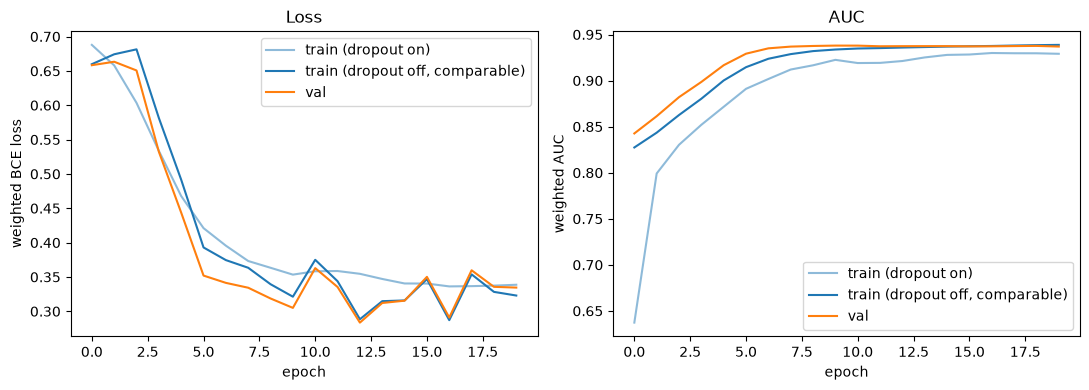

Final weighted val AUC = 0.9380


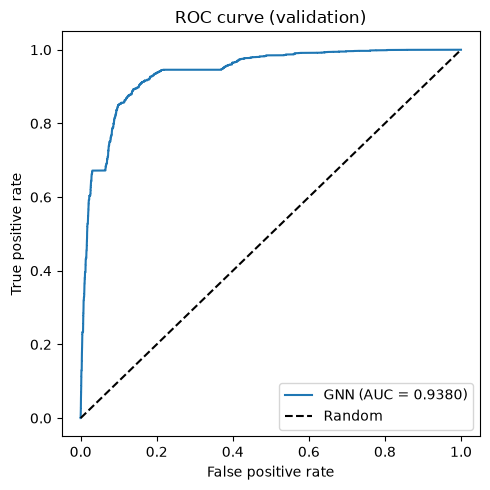

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history["train_loss"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[0].plot(history["train_loss_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[0].plot(history["val_loss"], label="val", color="tab:orange")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("weighted BCE loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["train_auc"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[1].plot(history["train_auc_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[1].plot(history["val_auc"], label="val", color="tab:orange")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("weighted AUC")
axes[1].set_title("AUC")
axes[1].legend()

plt.tight_layout()
plt.show()

y_val_scores = score_dataset(model, X_val).cpu().numpy()
y_val = y_val_labels.cpu().numpy()
w_val = w_val_abs.cpu().numpy()

auc_val = roc_auc_score(y_val, y_val_scores, sample_weight=w_val)
print(f"Final weighted val AUC = {auc_val:.4f}")

fpr, tpr, _ = roc_curve(y_val, y_val_scores, sample_weight=w_val)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"GNN (AUC = {auc_val:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve (validation)")
plt.legend()
plt.tight_layout()
plt.show()

## Feature Importance (Permutation)

Same approach as the 1l2tau GNN: shuffle one raw per-object column across
validation events, rebuild the node-feature tensor, measure the drop in
weighted validation AUC. Ranks the raw `REQUIRED_OBJECT_COLUMNS` (~25 here,
one more object's worth than 1l2tau's ~23), not the ~80 flat MLP features -
expect noticeably fewer bars than 30, that's by design.

In [ ]:
def score_node_features(model, node_features_np, chunk_size=4096):
    model.eval()
    n = node_features_np.shape[0]
    probs = np.empty(n, dtype=np.float32)
    edge_index_cpu = EDGE_INDEX

    for start in range(0, n, chunk_size):
        chunk = node_features_np[start:start + chunk_size]
        b = chunk.shape[0]
        x = torch.from_numpy(chunk.reshape(-1, N_NODE_FEATURES)).to(DEVICE)
        offsets = torch.arange(b, device=DEVICE) * N_NODES
        edge_index_chunk = (edge_index_cpu[:, None, :] + offsets[None, :, None]).reshape(2, -1).to(DEVICE)
        batch_vec = torch.repeat_interleave(torch.arange(b, device=DEVICE), N_NODES)
        with torch.no_grad():
            logits = model(x, edge_index_chunk, batch_vec)
        probs[start:start + b] = torch.sigmoid(logits).cpu().numpy()

    return probs


def permutation_importance_gnn(model, val_scaled, val_imp, y, w, columns, n_repeats=5, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    n = len(val_scaled)

    baseline_probs = score_node_features(model, stack_node_features(val_scaled, val_imp))
    baseline_auc = roc_auc_score(y, baseline_probs, sample_weight=w)
    print(f"Baseline weighted AUC: {baseline_auc:.4f}")

    mean_drops = []
    for col in columns:
        drops = []
        for _ in range(n_repeats):
            perm = rng.permutation(n)
            vs, vi = val_scaled.copy(), val_imp.copy()
            if col in vs.columns:
                vs[col] = vs[col].to_numpy()[perm]
            if col in vi.columns:
                vi[col] = vi[col].to_numpy()[perm]
            probs = score_node_features(model, stack_node_features(vs, vi))
            drops.append(baseline_auc - roc_auc_score(y, probs, sample_weight=w))
        mean_drops.append(np.mean(drops))

    return pd.Series(mean_drops, index=columns, name="auc_drop").sort_values(ascending=False)


def plot_importance_bar(imp, top_n=30, title="", color="lightblue", save_path=None):
    n = min(top_n, len(imp))
    fig, ax = plt.subplots(figsize=(8, max(4, 0.28 * n)))
    imp.head(top_n)[::-1].plot.barh(ax=ax, color=color)
    ax.set_xlabel("Weighted AUC drop when shuffled")
    ax.set_title(title)
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150)
        print(f"Saved plot -> {save_path}")

    plt.show()

Baseline weighted AUC: 0.9380


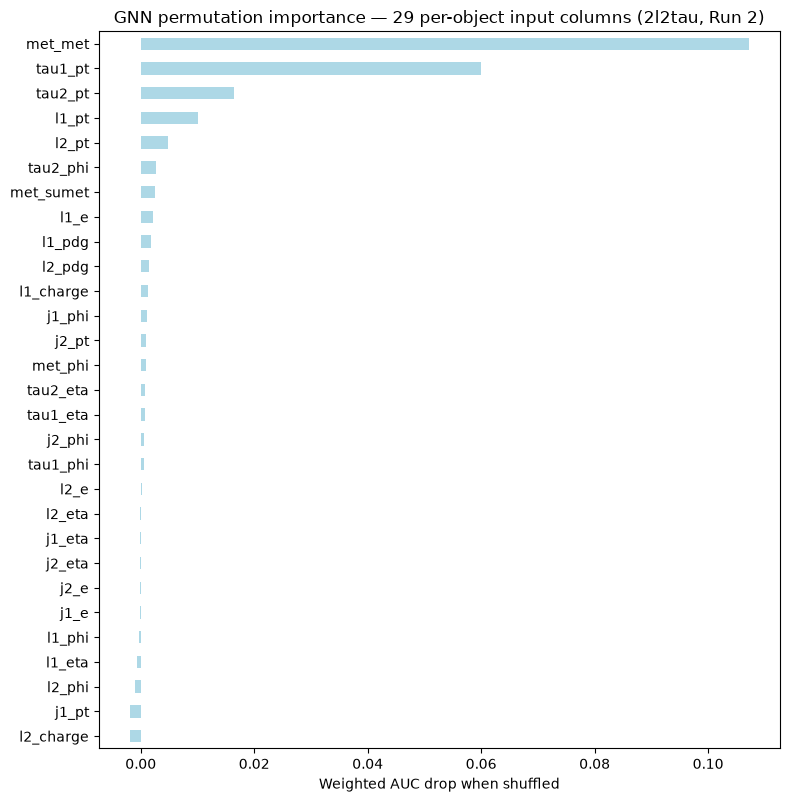

met_met      0.107210
tau1_pt      0.060048
tau2_pt      0.016397
l1_pt        0.010044
l2_pt        0.004885
tau2_phi     0.002607
met_sumet    0.002488
l1_e         0.002071
l1_pdg       0.001723
l2_pdg       0.001517
l1_charge    0.001364
j1_phi       0.001034
j2_pt        0.000912
met_phi      0.000901
tau2_eta     0.000704
tau1_eta     0.000703
j2_phi       0.000565
tau1_phi     0.000532
l2_e         0.000296
l2_eta      -0.000046
j1_eta      -0.000050
j2_eta      -0.000123
j2_e        -0.000213
j1_e        -0.000220
l1_phi      -0.000320
l1_eta      -0.000621
l2_phi      -0.000945
j1_pt       -0.001826
l2_charge   -0.001951
Name: auc_drop, dtype: float64

In [ ]:
importance = permutation_importance_gnn(
    model, val_scaled, val_imp, y_val, w_val, REQUIRED_OBJECT_COLUMNS, n_repeats=5,
)
plot_importance_bar(
    importance, top_n=30,
    title=f"GNN permutation importance — {len(REQUIRED_OBJECT_COLUMNS)} per-object input columns (2l2tau, Run 2)",
)
importance

## Physics Figure of Merit & Held-Out Test Evaluation

Same max-Asimov-significance scan as `DNN_2l2tau.ipynb`. Score cut selected
on VAL only, then applied frozen to TEST, scored exactly once.

In [ ]:
def significance_scan(y_true, scores, w_phys, n_thr=200, min_bkg=1.0):
    thr = np.quantile(scores, np.linspace(0, 1, n_thr))
    best_z, best_t = 0.0, None

    for t in thr:
        sel = scores >= t
        S = w_phys[sel & (y_true == 1)].sum()
        B = w_phys[sel & (y_true == 0)].sum()
        if S <= 0 or B < min_bkg:
            continue
        z = np.sqrt(2 * ((S + B) * np.log(1 + S / B) - S))
        if z > best_z:
            best_z, best_t = z, t

    return best_z, best_t


w_val_signed = val_df["w_phys"].to_numpy()
z_val, thr_val = significance_scan(y_val, y_val_scores, w_val_signed)

print(f"Weighted val AUC = {auc_val:.4f}")
print(f"Max Asimov Z (val) = {z_val:.3f} at score cut = {thr_val:.4f}")

# ---- HELD-OUT TEST EVALUATION - scored EXACTLY ONCE ------------------------
test_scores = score_dataset(model, X_test).cpu().numpy()
y_test = y_test_labels.cpu().numpy()
w_test_abs = w_test_abs_t.cpu().numpy()
w_test_signed = test_df["w_phys"].to_numpy()

auc_test = roc_auc_score(y_test, test_scores, sample_weight=w_test_abs)

S_test = w_test_signed[(test_scores >= thr_val) & (y_test == 1)].sum()
B_test = w_test_signed[(test_scores >= thr_val) & (y_test == 0)].sum()
z_test = (np.sqrt(2 * ((S_test + B_test) * np.log(1 + S_test / B_test) - S_test))
          if (S_test > 0 and B_test > 0) else np.nan)

print(f"\nWeighted AUC: val = {auc_val:.4f}  |  test (held-out, scored once) = {auc_test:.4f}")
print(f"At the VAL-selected score cut = {thr_val:.4f} (frozen, NOT re-scanned on test):")
print(f"  test S = {S_test:.2f} | test B = {B_test:.2f} | test Z = {z_test:.3f}  (val Z was {z_val:.3f})")

Weighted val AUC = 0.9380
Max Asimov Z (val) = 0.015 at score cut = 0.8190

Weighted AUC: val = 0.9380  |  test (held-out, scored once) = 0.9396
At the VAL-selected score cut = 0.8190 (frozen, NOT re-scanned on test):
  test S = 0.02 | test B = 4.06 | test Z = 0.012  (val Z was 0.015)


## Sanity Checks & Summary

In [ ]:
set_seed(RANDOM_STATE)
_, _, det_check_a, _, _ = train_model(hidden_channels=16, n_epochs=5, patience=5, verbose=False)

set_seed(RANDOM_STATE)
_, _, det_check_b, _, _ = train_model(hidden_channels=16, n_epochs=5, patience=5, verbose=False)
assert det_check_a == det_check_b, f"Determinism check FAILED: {det_check_a} != {det_check_b}"

print(f"Determinism check passed: two re-seeded runs give identical val_auc = {det_check_a:.6f}")

summary = pd.DataFrame([{
    "model": f"GNN (object nodes, {N_NODES} nodes/event)",
    "val_auc": auc_val,
    "max_asimov_Z (val)": z_val,
    "test_auc (held-out, scored once)": auc_test,
    "test_Z_at_val_cut (held-out)": z_test,
}])

print("\nFinal summary (GNN, 2l2tau Run 2):")
print(summary.to_string(index=False))
summary

/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/es

Determinism check passed: two re-seeded runs give identical val_auc = 0.877285

Final summary (GNN, 2l2tau Run 2):
                            model  val_auc  max_asimov_Z (val)  test_auc (held-out, scored once)  test_Z_at_val_cut (held-out)
GNN (object nodes, 7 nodes/event) 0.937985             0.01493                          0.939557                      0.012104


,model,val_auc,max_asimov_Z (val),"test_auc (held-out, scored once)",test_Z_at_val_cut (held-out)
0,"GNN (object nodes, 7 nodes/event)",0.937985,0.01493,0.939557,0.012104


## Run 3 (Separate Downstream Section)

Run 2 remains the first complete pass above. This section switches the
active dataset to Run 3 and reuses every function/class defined in the
Run 2 section above unchanged - only the data and everything derived from
it get `_run3`-suffixed variable names.

## Load Run 3 Data

In [38]:
candidate_features_run3 = discover_common_features(BASE_DIR_RUN3)
data_run3 = load_run_data(BASE_DIR_RUN3, candidate_features_run3)
data_run3, features_run3 = clean_data(data_run3, candidate_features_run3)

BASE_DIR = BASE_DIR_RUN3
ACTIVE_RUN = "Run 3"

print(f"\nLoaded {len(data_run3)} events | {len(features_run3)} leakage-free features available (Run 3)")

88 candidate features (common to all 10 processes, leakage-free)
signal_ggF  :    96909 events after preselection
signal_VBF  :     3439 events after preselection
Diboson     :    82336 events after preselection
Zjets       :    12919 events after preselection
Wjets       :       51 events after preselection
ttbar       :     3276 events after preselection
tops        :    11065 events after preselection
SingleH     :     3240 events after preselection
Vgamma      :     2366 events after preselection
VVV         :    13941 events after preselection
Dropped 7 constant/empty features:
  ['dR_j1j2_l1', 'dR_j1j2_t1', 'dR_j1j2_t2', 'n_lep', 'tau1_base_id', 'tau2_base_id', 'xgb_score']

81 final features
Total: 229542 events | signal = 100348 | background = 129194
Yield (w_phys): signal = 0.49 | background = 2126.09

Loaded 229542 events | 81 leakage-free features available (Run 3)


## Sentinel Audit (-1) — Run 3

Same diagnostic as the Run 2 section above, run separately on `data_run3`/
`features_run3`.

In [39]:
NEG1_SENTINEL_FEATURES_run3 = set()

neg1_rows_run3 = []
for f in features_run3:
    vals = data_run3[f]
    frac_neg1 = (vals == -1).mean()
    if frac_neg1 == 0:
        continue
    above = vals[vals > -1]
    gap = (above.min() - (-1)) if len(above) else np.nan
    neg1_rows_run3.append({"feature": f, "frac_exactly_-1": frac_neg1, "gap_to_next_value_above": gap})

neg1_df_run3 = pd.DataFrame(neg1_rows_run3).sort_values("frac_exactly_-1", ascending=False)
print(f"{len(neg1_df_run3)} / {len(features_run3)} features have at least one row exactly equal to -1:")
print(neg1_df_run3.to_string(index=False))

for f in NEG1_SENTINEL_FEATURES_run3:
    data_run3[f] = data_run3[f].mask(data_run3[f] == -1)

if NEG1_SENTINEL_FEATURES_run3:
    print(f"\nMasked -1 -> NaN for: {sorted(NEG1_SENTINEL_FEATURES_run3)}")
else:
    print("\nNEG1_SENTINEL_FEATURES_run3 is empty - no -1 values masked.")

2 / 81 features have at least one row exactly equal to -1:
  feature  frac_exactly_-1  gap_to_next_value_above
l1_charge         0.504539                      2.0
l2_charge         0.495461                      2.0

NEG1_SENTINEL_FEATURES_run3 is empty - no -1 values masked.


## Train/Validation/Test Split — Run 3

Same deterministic two-stage stratified 80/10/10 split as the Run 2
section, applied to `data_run3`, cross-checked against any persisted Run 3
test partition.

In [40]:
train_df_run3, val_df_run3, test_df_run3 = make_3way_split(data_run3)

SPLIT_DIR_RUN3 = BASE_DIR_RUN3 / "splits"
assert_same_test_partition(test_df_run3, SPLIT_DIR_RUN3 / "test.root")

Train:   183632 events | signal =   80278 (yield=      0.39) | background =  103354 (yield=   1697.83) | signal weight scale factor = 4319.8
Val  :    22955 events | signal =   10035 (yield=      0.05) | background =   12920 (yield=    264.85) | signal weight scale factor = 5344.6
Test :    22955 events | signal =   10035 (yield=      0.05) | background =   12920 (yield=    163.42) | signal weight scale factor = 3343.2
  cross-check OK: PPSSP_2026/2l2tau/run3/splits/test.root test partition matches on 86 shared columns (22955 rows)


## Node/Graph Preprocessing — Run 3

The object/node schema (`OBJECT_COLUMNS`, `NODE_ORDER`, `NODE_TYPE`,
`TYPE_LIST`, `N_NODES`, `N_NODE_FEATURES`, `EDGE_INDEX`,
`CONTINUOUS_NODE_COLS`) is run-independent, reused unchanged from the Run 2
section. Median imputation and standard scaling are refit on the Run 3
train split only.

In [41]:
missing_run3 = [c for c in REQUIRED_OBJECT_COLUMNS if c not in features_run3]
assert not missing_run3, f"Node schema references columns dropped by clean_data / the leakage policy (Run 3): {missing_run3}"

train_medians_run3 = train_df_run3[REQUIRED_OBJECT_COLUMNS].median()

train_imp_run3 = train_df_run3[REQUIRED_OBJECT_COLUMNS].fillna(train_medians_run3)
val_imp_run3 = val_df_run3[REQUIRED_OBJECT_COLUMNS].fillna(train_medians_run3)
test_imp_run3 = test_df_run3[REQUIRED_OBJECT_COLUMNS].fillna(train_medians_run3)

scaler_run3 = StandardScaler()
train_scaled_run3 = train_imp_run3.copy()
val_scaled_run3 = val_imp_run3.copy()
test_scaled_run3 = test_imp_run3.copy()
train_scaled_run3[CONTINUOUS_NODE_COLS] = scaler_run3.fit_transform(train_imp_run3[CONTINUOUS_NODE_COLS])
val_scaled_run3[CONTINUOUS_NODE_COLS] = scaler_run3.transform(val_imp_run3[CONTINUOUS_NODE_COLS])
test_scaled_run3[CONTINUOUS_NODE_COLS] = scaler_run3.transform(test_imp_run3[CONTINUOUS_NODE_COLS])

assert np.isfinite(train_scaled_run3.to_numpy()).all(), "NaN/inf reached the model input (train, Run 3)"
assert np.isfinite(val_scaled_run3.to_numpy()).all(), "NaN/inf reached the model input (val, Run 3)"
assert np.isfinite(test_scaled_run3.to_numpy()).all(), "NaN/inf reached the model input (test, Run 3)"

print("Imputation + scaling done (fit on Run 3 train only).")

Imputation + scaling done (fit on Run 3 train only).


## Graph Construction — Run 3

Reuses `stack_node_features`/`build_graph_tensors` from the Run 2 section
unchanged, applied to the Run 3 scaled/imputed splits.

In [42]:
w_train_fit_run3 = make_fit_weights(train_df_run3["label"].to_numpy(), np.abs(train_df_run3["w_phys"].to_numpy()))

X_train_run3, y_train_run3, w_train_fit_t_run3, w_train_eval_t_run3 = build_graph_tensors(
    train_scaled_run3, train_imp_run3, train_df_run3, fit_weights=w_train_fit_run3,
)
X_val_run3, y_val_labels_run3, _, w_val_abs_run3 = build_graph_tensors(val_scaled_run3, val_imp_run3, val_df_run3)
X_test_run3, y_test_labels_run3, _, w_test_abs_t_run3 = build_graph_tensors(test_scaled_run3, test_imp_run3, test_df_run3)

print(f"Built {X_train_run3.shape[0]} train / {X_val_run3.shape[0]} val / {X_test_run3.shape[0]} test graphs (Run 3)")

Built 183632 train / 22955 val / 22955 test graphs (Run 3)


## Training Loop — Run 3

Reuses `train_model`/`run_epoch`/`build_model`/`ObjectGNN` from the Run 2
section unchanged, with explicit `_run3` tensors passed in so the Run 2
model/history are untouched.

In [43]:
model_run3, history_run3, best_val_auc_run3, best_train_auc_run3, best_train_auc_eval_run3 = train_model(
    X_train_data=X_train_run3, y_train_data=y_train_run3,
    w_train_fit_data=w_train_fit_t_run3, w_train_eval_data=w_train_eval_t_run3,
    X_val_data=X_val_run3, y_val_data=y_val_labels_run3, w_val_data=w_val_abs_run3,
)

print(f"\nBest val_auc = {best_val_auc_run3:.4f} | train_auc (dropout on) = {best_train_auc_run3:.4f} "
      f"| train_auc_eval (dropout off, comparable) = {best_train_auc_eval_run3:.4f}")

/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch   1 | train_loss=0.6653 val_loss=0.6729 | train_auc=0.7496 train_auc_eval=0.8935 val_auc=0.8960


/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch   2 | train_loss=0.5074 val_loss=0.5019 | train_auc=0.8833 train_auc_eval=0.9243 val_auc=0.9312


/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


...

Epoch  48 | train_loss=0.2860 val_loss=0.2923 | train_auc=0.9499 train_auc_eval=0.9535 val_auc=0.9549


/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch  49 | train_loss=0.2867 val_loss=0.2683 | train_auc=0.9498 train_auc_eval=0.9537 val_auc=0.9555


/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch  50 | train_loss=0.2882 val_loss=0.2948 | train_auc=0.9493 train_auc_eval=0.9539 val_auc=0.9559

Best val_auc = 0.9559 | train_auc (dropout on) = 0.9493 | train_auc_eval (dropout off, comparable) = 0.9539


## Evaluation — Run 3

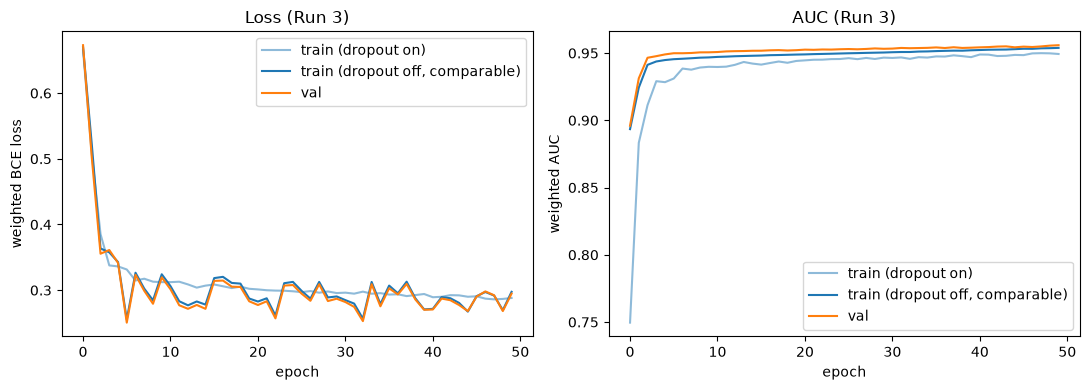

Final weighted val AUC (Run 3) = 0.9559


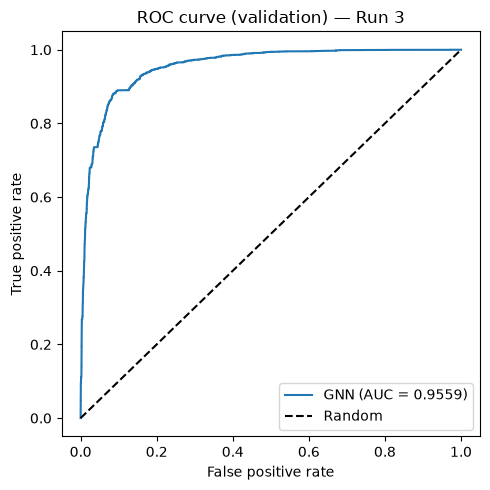

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history_run3["train_loss"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[0].plot(history_run3["train_loss_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[0].plot(history_run3["val_loss"], label="val", color="tab:orange")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("weighted BCE loss")
axes[0].set_title("Loss (Run 3)")
axes[0].legend()

axes[1].plot(history_run3["train_auc"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[1].plot(history_run3["train_auc_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[1].plot(history_run3["val_auc"], label="val", color="tab:orange")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("weighted AUC")
axes[1].set_title("AUC (Run 3)")
axes[1].legend()

plt.tight_layout()
plt.show()

y_val_scores_run3 = score_dataset(model_run3, X_val_run3).cpu().numpy()
y_val_run3 = y_val_labels_run3.cpu().numpy()
w_val_run3 = w_val_abs_run3.cpu().numpy()

auc_val_run3 = roc_auc_score(y_val_run3, y_val_scores_run3, sample_weight=w_val_run3)
print(f"Final weighted val AUC (Run 3) = {auc_val_run3:.4f}")

fpr_run3, tpr_run3, _ = roc_curve(y_val_run3, y_val_scores_run3, sample_weight=w_val_run3)
plt.figure(figsize=(5, 5))
plt.plot(fpr_run3, tpr_run3, label=f"GNN (AUC = {auc_val_run3:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve (validation) — Run 3")
plt.legend()
plt.tight_layout()
plt.show()

## Feature Importance (Permutation) — Run 3

Reuses `permutation_importance_gnn`/`score_node_features`/
`plot_importance_bar` from the Run 2 section unchanged.

Baseline weighted AUC: 0.9559


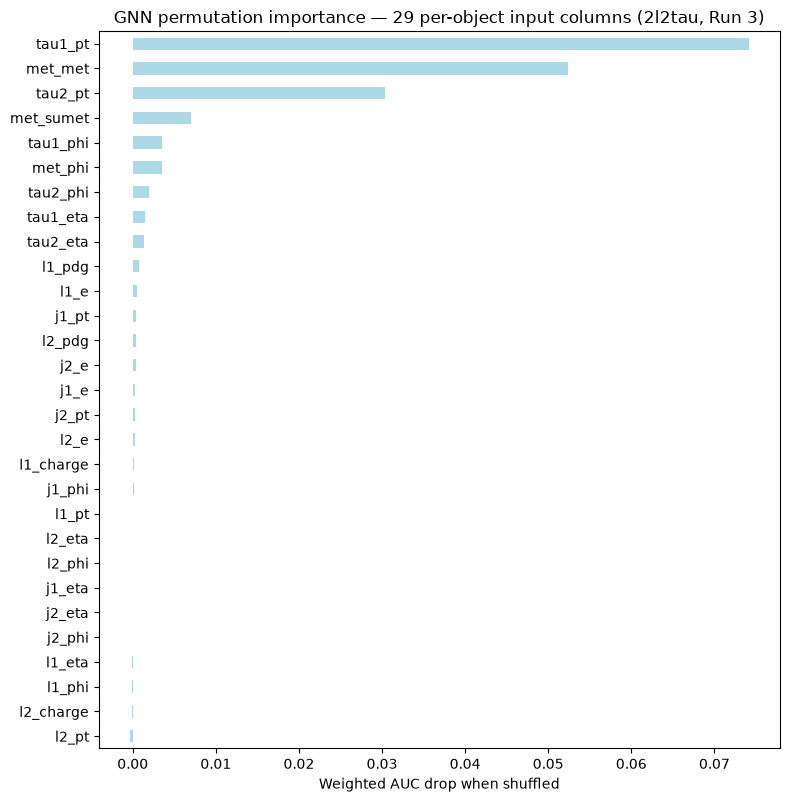

tau1_pt      0.074165
met_met      0.052395
tau2_pt      0.030406
met_sumet    0.006964
tau1_phi     0.003532
met_phi      0.003475
tau2_phi     0.001955
tau1_eta     0.001456
tau2_eta     0.001406
l1_pdg       0.000811
l1_e         0.000502
j1_pt        0.000360
l2_pdg       0.000345
j2_e         0.000339
j1_e         0.000266
j2_pt        0.000259
l2_e         0.000257
l1_charge    0.000151
j1_phi       0.000105
l1_pt        0.000093
l2_eta       0.000087
l2_phi       0.000071
j1_eta       0.000046
j2_eta       0.000036
j2_phi      -0.000026
l1_eta      -0.000040
l1_phi      -0.000110
l2_charge   -0.000115
l2_pt       -0.000366
Name: auc_drop, dtype: float64

In [45]:
importance_run3 = permutation_importance_gnn(
    model_run3, val_scaled_run3, val_imp_run3, y_val_run3, w_val_run3, REQUIRED_OBJECT_COLUMNS, n_repeats=5,
)
plot_importance_bar(
    importance_run3, top_n=30,
    title=f"GNN permutation importance — {len(REQUIRED_OBJECT_COLUMNS)} per-object input columns (2l2tau, Run 3)",
)
importance_run3

## Physics Figure of Merit & Held-Out Test Evaluation — Run 3

Reuses `significance_scan` from the Run 2 section. The score cut is
selected by scanning Run 3's own VAL only, then applied frozen to Run 3
TEST, scored exactly once.

In [46]:
w_val_signed_run3 = val_df_run3["w_phys"].to_numpy()
z_val_run3, thr_val_run3 = significance_scan(y_val_run3, y_val_scores_run3, w_val_signed_run3)

print(f"Weighted val AUC (Run 3) = {auc_val_run3:.4f}")
print(f"Max Asimov Z (val, Run 3) = {z_val_run3:.3f} at score cut = {thr_val_run3:.4f}")

# ---- HELD-OUT TEST EVALUATION (Run 3) - scored EXACTLY ONCE ----------------
test_scores_run3 = score_dataset(model_run3, X_test_run3).cpu().numpy()
y_test_run3 = y_test_labels_run3.cpu().numpy()
w_test_abs_run3 = w_test_abs_t_run3.cpu().numpy()
w_test_signed_run3 = test_df_run3["w_phys"].to_numpy()

auc_test_run3 = roc_auc_score(y_test_run3, test_scores_run3, sample_weight=w_test_abs_run3)

S_test_run3 = w_test_signed_run3[(test_scores_run3 >= thr_val_run3) & (y_test_run3 == 1)].sum()
B_test_run3 = w_test_signed_run3[(test_scores_run3 >= thr_val_run3) & (y_test_run3 == 0)].sum()
z_test_run3 = (np.sqrt(2 * ((S_test_run3 + B_test_run3) * np.log(1 + S_test_run3 / B_test_run3) - S_test_run3))
               if (S_test_run3 > 0 and B_test_run3 > 0) else np.nan)

print(f"\nWeighted AUC (Run 3): val = {auc_val_run3:.4f}  |  test (held-out, scored once) = {auc_test_run3:.4f}")
print(f"At the VAL-selected score cut = {thr_val_run3:.4f} (frozen, NOT re-scanned on test):")
print(f"  test S = {S_test_run3:.2f} | test B = {B_test_run3:.2f} | test Z = {z_test_run3:.3f}  (val Z was {z_val_run3:.3f})")

Weighted val AUC (Run 3) = 0.9559
Max Asimov Z (val, Run 3) = 0.013 at score cut = 0.9094

Weighted AUC (Run 3): val = 0.9559  |  test (held-out, scored once) = 0.9443
At the VAL-selected score cut = 0.9094 (frozen, NOT re-scanned on test):
  test S = 0.02 | test B = 4.66 | test Z = 0.011  (val Z was 0.013)


## Sanity Checks & Summary — Run 3

In [47]:
set_seed(RANDOM_STATE)
_, _, det_check_a_run3, _, _ = train_model(
    hidden_channels=16, n_epochs=5, patience=5, verbose=False,
    X_train_data=X_train_run3, y_train_data=y_train_run3,
    w_train_fit_data=w_train_fit_t_run3, w_train_eval_data=w_train_eval_t_run3,
    X_val_data=X_val_run3, y_val_data=y_val_labels_run3, w_val_data=w_val_abs_run3,
)

set_seed(RANDOM_STATE)
_, _, det_check_b_run3, _, _ = train_model(
    hidden_channels=16, n_epochs=5, patience=5, verbose=False,
    X_train_data=X_train_run3, y_train_data=y_train_run3,
    w_train_fit_data=w_train_fit_t_run3, w_train_eval_data=w_train_eval_t_run3,
    X_val_data=X_val_run3, y_val_data=y_val_labels_run3, w_val_data=w_val_abs_run3,
)
assert det_check_a_run3 == det_check_b_run3, f"Determinism check FAILED (Run 3): {det_check_a_run3} != {det_check_b_run3}"

print(f"Determinism check passed (Run 3): two re-seeded runs give identical val_auc = {det_check_a_run3:.6f}")

summary_run3 = pd.DataFrame([{
    "model": f"GNN (object nodes, {N_NODES} nodes/event)",
    "val_auc": auc_val_run3,
    "max_asimov_Z (val)": z_val_run3,
    "test_auc (held-out, scored once)": auc_test_run3,
    "test_Z_at_val_cut (held-out)": z_test_run3,
}])

print("\nFinal summary (GNN, 2l2tau Run 3):")
print(summary_run3.to_string(index=False))
summary_run3

/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/es

Determinism check passed (Run 3): two re-seeded runs give identical val_auc = 0.923044

Final summary (GNN, 2l2tau Run 3):
                            model  val_auc  max_asimov_Z (val)  test_auc (held-out, scored once)  test_Z_at_val_cut (held-out)
GNN (object nodes, 7 nodes/event) 0.955854            0.012847                          0.944296                      0.011118


,model,val_auc,max_asimov_Z (val),"test_auc (held-out, scored once)",test_Z_at_val_cut (held-out)
0,"GNN (object nodes, 7 nodes/event)",0.955854,0.012847,0.944296,0.011118


## Combined Run 2 + Run 3 (Separate Downstream Section)

Same convention as the Run 3 section above: reuses every function/class
from the Run 2 section unchanged - only the data and everything derived
from it get `_comb`-suffixed variable names. Requires the Run 2 and Run 3
sections above to have already run in this kernel.

## Load Combined Data

Concatenate Run 2 and Run 3 with a `run` tag column, restricted to
features common to BOTH runs (the intersection).

In [48]:
# NOTE: this section reuses `features`/`data` (Run 2, first pass) as
# `features_run2`/`data_run2` was never defined under those exact names in
# this notebook - Run 2 above kept the unsuffixed `data`/`features`. Alias
# them here so the intersection logic below reads the same as DNN_2l2tau.ipynb.
data_run2, features_run2 = data, features

candidate_features_comb = sorted(set(features_run2) & set(features_run3))
keep_cols_comb = candidate_features_comb + ["w_phys", "label", "process"]

data_run2_tagged = data_run2[keep_cols_comb].copy()
data_run2_tagged["run"] = 2

data_run3_tagged = data_run3[keep_cols_comb].copy()
data_run3_tagged["run"] = 3

data_comb_raw = pd.concat([data_run2_tagged, data_run3_tagged], ignore_index=True)
data_comb, features_comb = clean_data(data_comb_raw, candidate_features_comb)

print(f"\nCombined: {len(data_comb)} events, {len(features_comb)} features "
      f"(intersection of Run2's {len(features_run2)} and Run3's {len(features_run3)})")

Dropped 0 constant/empty features:
  []

81 final features
Total: 324510 events | signal = 137905 | background = 186605
Yield (w_phys): signal = 0.91 | background = 3160.25

Combined: 324510 events, 81 features (intersection of Run2's 81 and Run3's 81)


## Sentinel Audit (-1) — Combined

Same diagnostic as the Run 2/Run 3 sections, run separately on `data_comb`/
`features_comb`.

In [49]:
NEG1_SENTINEL_FEATURES_comb = set()

neg1_rows_comb = []
for f in features_comb:
    vals = data_comb[f]
    frac_neg1 = (vals == -1).mean()
    if frac_neg1 == 0:
        continue
    above = vals[vals > -1]
    gap = (above.min() - (-1)) if len(above) else np.nan
    neg1_rows_comb.append({"feature": f, "frac_exactly_-1": frac_neg1, "gap_to_next_value_above": gap})

neg1_df_comb = pd.DataFrame(neg1_rows_comb).sort_values("frac_exactly_-1", ascending=False)
print(f"{len(neg1_df_comb)} / {len(features_comb)} features have at least one row exactly equal to -1:")
print(neg1_df_comb.to_string(index=False))

for f in NEG1_SENTINEL_FEATURES_comb:
    data_comb[f] = data_comb[f].mask(data_comb[f] == -1)

if NEG1_SENTINEL_FEATURES_comb:
    print(f"\nMasked -1 -> NaN for: {sorted(NEG1_SENTINEL_FEATURES_comb)}")
else:
    print("\nNEG1_SENTINEL_FEATURES_comb is empty - no -1 values masked.")

2 / 81 features have at least one row exactly equal to -1:
  feature  frac_exactly_-1  gap_to_next_value_above
l1_charge         0.504625                      2.0
l2_charge         0.495375                      2.0

NEG1_SENTINEL_FEATURES_comb is empty - no -1 values masked.


## Train/Validation/Test Split — Combined

Same deterministic 80/10/10 split, stratified on `label` AND `run`
together, cross-checked against any persisted Combined test partition.

In [50]:
train_df_comb, val_df_comb, test_df_comb = make_3way_split(data_comb, extra_stratify_col="run")

BASE_DIR_COMB = Path("PPSSP_2026/2l2tau/combined")
SPLIT_DIR_COMB = BASE_DIR_COMB / "splits"
assert_same_test_partition(test_df_comb, SPLIT_DIR_COMB / "test.root")

Train:   259607 events | signal =  110323 (yield=      0.73) | background =  149284 (yield=   2563.46) | signal weight scale factor = 3527.6
Val  :    32452 events | signal =   13791 (yield=      0.09) | background =   18661 (yield=    295.44) | signal weight scale factor = 3279.1
Test :    32451 events | signal =   13791 (yield=      0.09) | background =   18660 (yield=    301.35) | signal weight scale factor = 3299.4
  cross-check OK: PPSSP_2026/2l2tau/combined/splits/test.root test partition matches on 84 shared columns (32451 rows)


## Node/Graph Preprocessing — Combined

Node schema reused unchanged from Run 2. Imputation and scaling refit on
the Combined train split only.

In [51]:
missing_comb = [c for c in REQUIRED_OBJECT_COLUMNS if c not in features_comb]
assert not missing_comb, f"Node schema references columns dropped by clean_data / the leakage policy (Combined): {missing_comb}"

train_medians_comb = train_df_comb[REQUIRED_OBJECT_COLUMNS].median()

train_imp_comb = train_df_comb[REQUIRED_OBJECT_COLUMNS].fillna(train_medians_comb)
val_imp_comb = val_df_comb[REQUIRED_OBJECT_COLUMNS].fillna(train_medians_comb)
test_imp_comb = test_df_comb[REQUIRED_OBJECT_COLUMNS].fillna(train_medians_comb)

scaler_comb = StandardScaler()
train_scaled_comb = train_imp_comb.copy()
val_scaled_comb = val_imp_comb.copy()
test_scaled_comb = test_imp_comb.copy()
train_scaled_comb[CONTINUOUS_NODE_COLS] = scaler_comb.fit_transform(train_imp_comb[CONTINUOUS_NODE_COLS])
val_scaled_comb[CONTINUOUS_NODE_COLS] = scaler_comb.transform(val_imp_comb[CONTINUOUS_NODE_COLS])
test_scaled_comb[CONTINUOUS_NODE_COLS] = scaler_comb.transform(test_imp_comb[CONTINUOUS_NODE_COLS])

assert np.isfinite(train_scaled_comb.to_numpy()).all(), "NaN/inf reached the model input (train, Combined)"
assert np.isfinite(val_scaled_comb.to_numpy()).all(), "NaN/inf reached the model input (val, Combined)"
assert np.isfinite(test_scaled_comb.to_numpy()).all(), "NaN/inf reached the model input (test, Combined)"

print("Imputation + scaling done (fit on Combined train only).")

Imputation + scaling done (fit on Combined train only).


## Graph Construction — Combined

Reuses `stack_node_features`/`build_graph_tensors` from the Run 2 section
unchanged.

In [52]:
w_train_fit_comb = make_fit_weights(train_df_comb["label"].to_numpy(), np.abs(train_df_comb["w_phys"].to_numpy()))

X_train_comb, y_train_comb, w_train_fit_t_comb, w_train_eval_t_comb = build_graph_tensors(
    train_scaled_comb, train_imp_comb, train_df_comb, fit_weights=w_train_fit_comb,
)
X_val_comb, y_val_labels_comb, _, w_val_abs_comb = build_graph_tensors(val_scaled_comb, val_imp_comb, val_df_comb)
X_test_comb, y_test_labels_comb, _, w_test_abs_t_comb = build_graph_tensors(test_scaled_comb, test_imp_comb, test_df_comb)

print(f"Built {X_train_comb.shape[0]} train / {X_val_comb.shape[0]} val / {X_test_comb.shape[0]} test graphs (Combined)")

Built 259607 train / 32452 val / 32451 test graphs (Combined)


## Training Loop — Combined

Reuses `train_model`/`run_epoch`/`build_model`/`ObjectGNN` from the Run 2
section unchanged.

In [53]:
model_comb, history_comb, best_val_auc_comb, best_train_auc_comb, best_train_auc_eval_comb = train_model(
    X_train_data=X_train_comb, y_train_data=y_train_comb,
    w_train_fit_data=w_train_fit_t_comb, w_train_eval_data=w_train_eval_t_comb,
    X_val_data=X_val_comb, y_val_data=y_val_labels_comb, w_val_data=w_val_abs_comb,
)

print(f"\nBest val_auc = {best_val_auc_comb:.4f} | train_auc (dropout on) = {best_train_auc_comb:.4f} "
      f"| train_auc_eval (dropout off, comparable) = {best_train_auc_eval_comb:.4f}")

/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch   1 | train_loss=0.6391 val_loss=0.6547 | train_auc=0.7921 train_auc_eval=0.8970 val_auc=0.9016


/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch   2 | train_loss=0.4392 val_loss=0.3560 | train_auc=0.8907 train_auc_eval=0.9323 val_auc=0.9278


/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


...

Epoch  48 | train_loss=0.2895 val_loss=0.3209 | train_auc=0.9484 train_auc_eval=0.9525 val_auc=0.9435


/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch  49 | train_loss=0.2859 val_loss=0.3783 | train_auc=0.9495 train_auc_eval=0.9528 val_auc=0.9431


/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch  50 | train_loss=0.2871 val_loss=0.3443 | train_auc=0.9492 train_auc_eval=0.9531 val_auc=0.9443

Best val_auc = 0.9443 | train_auc (dropout on) = 0.9492 | train_auc_eval (dropout off, comparable) = 0.9531


## Evaluation — Combined

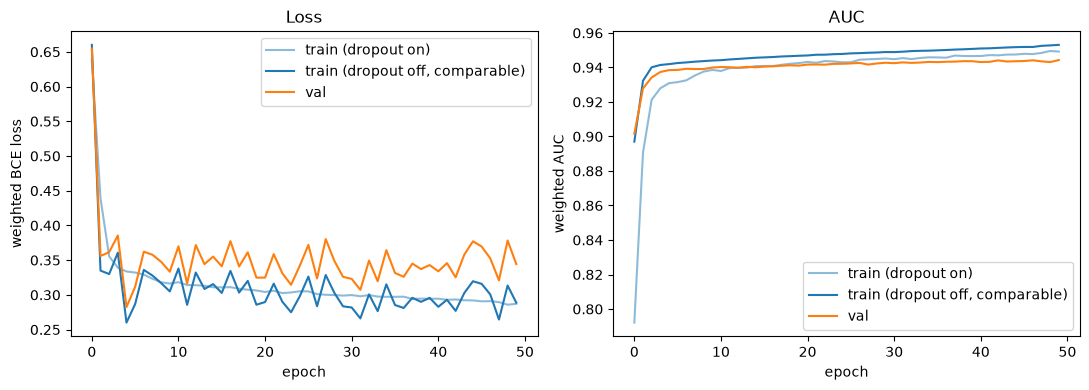

Final weighted val AUC (Combined) = 0.9443


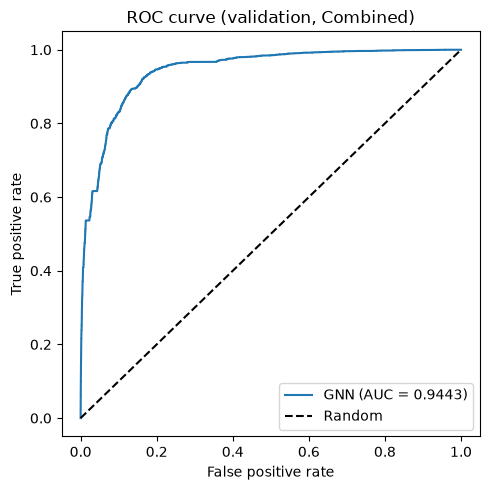

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history_comb["train_loss"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[0].plot(history_comb["train_loss_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[0].plot(history_comb["val_loss"], label="val", color="tab:orange")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("weighted BCE loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history_comb["train_auc"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[1].plot(history_comb["train_auc_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[1].plot(history_comb["val_auc"], label="val", color="tab:orange")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("weighted AUC")
axes[1].set_title("AUC")
axes[1].legend()

plt.tight_layout()
plt.show()

y_val_scores_comb = score_dataset(model_comb, X_val_comb).cpu().numpy()
y_val_comb = y_val_labels_comb.cpu().numpy()
w_val_comb = w_val_abs_comb.cpu().numpy()

auc_val_comb = roc_auc_score(y_val_comb, y_val_scores_comb, sample_weight=w_val_comb)
print(f"Final weighted val AUC (Combined) = {auc_val_comb:.4f}")

fpr_comb, tpr_comb, _ = roc_curve(y_val_comb, y_val_scores_comb, sample_weight=w_val_comb)
plt.figure(figsize=(5, 5))
plt.plot(fpr_comb, tpr_comb, label=f"GNN (AUC = {auc_val_comb:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve (validation, Combined)")
plt.legend()
plt.tight_layout()
plt.show()

## Feature Importance (Permutation) — Combined

Reuses `permutation_importance_gnn`/`score_node_features`/`plot_importance_bar`
from the Run 2 section unchanged.

Baseline weighted AUC: 0.9443


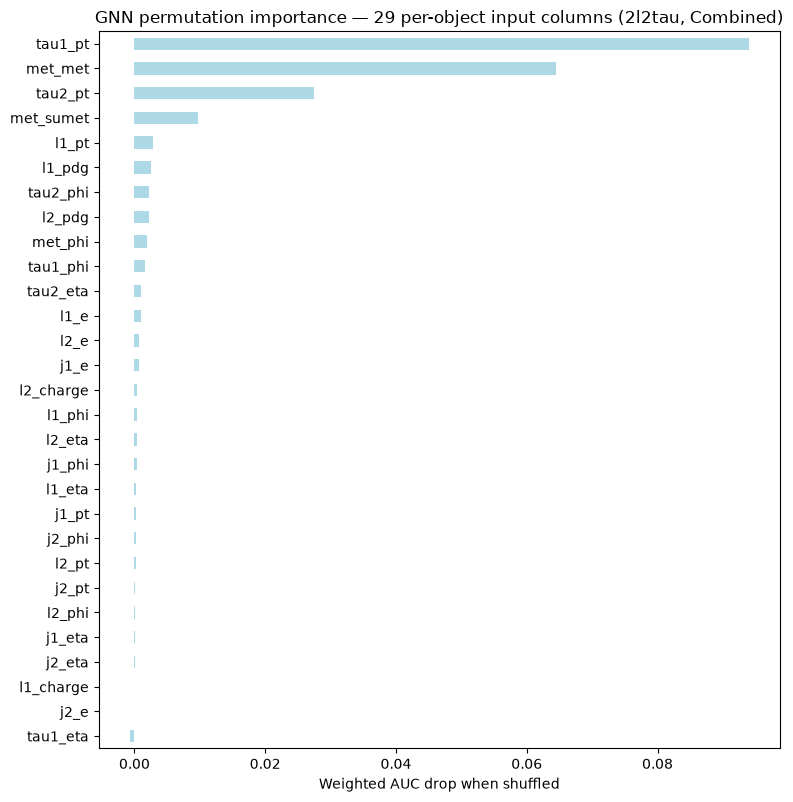

tau1_pt      0.093996
met_met      0.064444
tau2_pt      0.027441
met_sumet    0.009792
l1_pt        0.002775
l1_pdg       0.002499
tau2_phi     0.002211
l2_pdg       0.002205
met_phi      0.001886
tau1_phi     0.001657
tau2_eta     0.001073
l1_e         0.000953
l2_e         0.000700
j1_e         0.000699
l2_charge    0.000455
l1_phi       0.000417
l2_eta       0.000387
j1_phi       0.000369
l1_eta       0.000301
j1_pt        0.000245
j2_phi       0.000222
l2_pt        0.000167
j2_pt        0.000134
l2_phi       0.000117
j1_eta       0.000024
j2_eta       0.000014
l1_charge   -0.000030
j2_e        -0.000126
tau1_eta    -0.000726
Name: auc_drop, dtype: float64

In [55]:
importance_comb = permutation_importance_gnn(
    model_comb, val_scaled_comb, val_imp_comb, y_val_comb, w_val_comb, REQUIRED_OBJECT_COLUMNS, n_repeats=5,
)
plot_importance_bar(
    importance_comb, top_n=30,
    title=f"GNN permutation importance — {len(REQUIRED_OBJECT_COLUMNS)} per-object input columns (2l2tau, Combined)",
)
importance_comb

## Physics Figure of Merit & Held-Out Test Evaluation — Combined

Reuses `significance_scan` from the Run 2 section. Score cut selected on
the Combined VAL split only, applied frozen to the Combined TEST split,
scored exactly once.

In [56]:
w_val_signed_comb = val_df_comb["w_phys"].to_numpy()
z_val_comb, thr_val_comb = significance_scan(y_val_comb, y_val_scores_comb, w_val_signed_comb)

print(f"Weighted val AUC (Combined) = {auc_val_comb:.4f}")
print(f"Max Asimov Z (val, Combined) = {z_val_comb:.3f} at score cut = {thr_val_comb:.4f}")

# ---- HELD-OUT TEST EVALUATION (Combined) - scored EXACTLY ONCE ------------
test_scores_comb = score_dataset(model_comb, X_test_comb).cpu().numpy()
y_test_comb = y_test_labels_comb.cpu().numpy()
w_test_abs_comb = w_test_abs_t_comb.cpu().numpy()
w_test_signed_comb = test_df_comb["w_phys"].to_numpy()

auc_test_comb = roc_auc_score(y_test_comb, test_scores_comb, sample_weight=w_test_abs_comb)

S_test_comb = w_test_signed_comb[(test_scores_comb >= thr_val_comb) & (y_test_comb == 1)].sum()
B_test_comb = w_test_signed_comb[(test_scores_comb >= thr_val_comb) & (y_test_comb == 0)].sum()
z_test_comb = (np.sqrt(2 * ((S_test_comb + B_test_comb) * np.log(1 + S_test_comb / B_test_comb) - S_test_comb))
               if (S_test_comb > 0 and B_test_comb > 0) else np.nan)

print(f"\nWeighted AUC (Combined): val = {auc_val_comb:.4f}  |  test (held-out, scored once) = {auc_test_comb:.4f}")
print(f"At the VAL-selected score cut = {thr_val_comb:.4f} (frozen, NOT re-scanned on test):")
print(f"  test S = {S_test_comb:.2f} | test B = {B_test_comb:.2f} | test Z = {z_test_comb:.3f}  (val Z was {z_val_comb:.3f})")

Weighted val AUC (Combined) = 0.9443
Max Asimov Z (val, Combined) = 0.024 at score cut = 0.9324

Weighted AUC (Combined): val = 0.9443  |  test (held-out, scored once) = 0.9506
At the VAL-selected score cut = 0.9324 (frozen, NOT re-scanned on test):
  test S = 0.03 | test B = 2.95 | test Z = 0.016  (val Z was 0.024)


## Sanity Checks & Summary — Combined

In [57]:
set_seed(RANDOM_STATE)
_, _, det_check_a_comb, _, _ = train_model(
    hidden_channels=16, n_epochs=5, patience=5, verbose=False,
    X_train_data=X_train_comb, y_train_data=y_train_comb,
    w_train_fit_data=w_train_fit_t_comb, w_train_eval_data=w_train_eval_t_comb,
    X_val_data=X_val_comb, y_val_data=y_val_labels_comb, w_val_data=w_val_abs_comb,
)

set_seed(RANDOM_STATE)
_, _, det_check_b_comb, _, _ = train_model(
    hidden_channels=16, n_epochs=5, patience=5, verbose=False,
    X_train_data=X_train_comb, y_train_data=y_train_comb,
    w_train_fit_data=w_train_fit_t_comb, w_train_eval_data=w_train_eval_t_comb,
    X_val_data=X_val_comb, y_val_data=y_val_labels_comb, w_val_data=w_val_abs_comb,
)
assert det_check_a_comb == det_check_b_comb, f"Determinism check FAILED (Combined): {det_check_a_comb} != {det_check_b_comb}"

print(f"Determinism check passed (Combined): two re-seeded runs give identical val_auc = {det_check_a_comb:.6f}")

summary_comb = pd.DataFrame([{
    "model": f"GNN (object nodes, {N_NODES} nodes/event)",
    "val_auc": auc_val_comb,
    "max_asimov_Z (val)": z_val_comb,
    "test_auc (held-out, scored once)": auc_test_comb,
    "test_Z_at_val_cut (held-out)": z_test_comb,
}])

print("\nFinal summary (GNN, 2l2tau Combined Run2+Run3):")
print(summary_comb.to_string(index=False))
summary_comb

/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/est3ban3/IFJ_Pan/MVA-Project/.venv/lib/python3.12/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/home/es

Determinism check passed (Combined): two re-seeded runs give identical val_auc = 0.933358

Final summary (GNN, 2l2tau Combined Run2+Run3):
                            model  val_auc  max_asimov_Z (val)  test_auc (held-out, scored once)  test_Z_at_val_cut (held-out)
GNN (object nodes, 7 nodes/event) 0.944264            0.024205                          0.950618                      0.016479


,model,val_auc,max_asimov_Z (val),"test_auc (held-out, scored once)",test_Z_at_val_cut (held-out)
0,"GNN (object nodes, 7 nodes/event)",0.944264,0.024205,0.950618,0.016479
